# Day 5: Ad Campaign SQL Performance Dashboard

**Industry:** Marketing  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · sqlite3 · SQL · matplotlib · seaborn · performance metrics

**Data:** Synthetic ad campaign data mirroring real Google Ads / Facebook Ads Manager export structure — 1,092 rows across 6 channels, 6 months (Jan–Jun 2024)

---

## Who uses this
A **performance marketing manager** deciding how to reallocate next month's budget across channels. Instead of exporting CSVs from each platform and manually building pivot tables, they run this notebook to get a unified SQL-powered view of CPA, ROAS, and CTR across all channels in seconds.

## Problem
Marketing teams overspend on high-CPA channels because they lack a fast, unified view of cross-channel performance. Google Ads, Facebook, Instagram, YouTube, and Email all export data in different formats — without a SQL layer to unify them, budget decisions are made on gut feel or incomplete data.

## What we build
1. Load synthetic campaign data and inspect it
2. Load into SQLite — unified SQL layer across all channels
3. SQL analysis: CPA, ROAS, CTR, ROI by channel, campaign, audience, day
4. Identify best and worst performing segments
5. Visualise — 4-panel dashboard
6. Print budget reallocation recommendation

## Key metrics we calculate
| Metric | Formula | What it means |
|--------|---------|---------------|
| CTR | clicks / impressions | How compelling is the ad? |
| CPC | spend / clicks | How much per click? |
| CPA | spend / conversions | How much per customer acquired? |
| ROAS | revenue / spend | Revenue for every £1 spent |
| ROI % | (revenue - spend) / spend × 100 | True profitability |

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect the Data

In [2]:
df = pd.read_csv('ad_campaign_data.csv')

print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Channels: {df["channel"].unique().tolist()}')
print(f'Campaigns: {df["campaign"].unique().tolist()}')
print(f'Audiences: {df["audience"].unique().tolist()}')
print(f'\nTotal spend:    ${df["spend_usd"].sum():,.0f}')
print(f'Total revenue:  ${df["revenue_usd"].sum():,.0f}')
print(f'Total conversions: {df["conversions"].sum():,}')
df.head(5)

Shape: (1092, 10)
Date range: 2024-01-01 to 2024-06-30
Channels: ['Google Search', 'Google Display', 'Facebook Feed', 'Instagram Story', 'YouTube', 'Email']
Campaigns: ['Promo Sale', 'Brand Awareness Q1', 'Lead Gen Q1', 'Brand Awareness Q2', 'Lead Gen Q2', 'Retargeting Q1', 'Product Launch']
Audiences: ['Retargeting', 'Broad', 'Lookalike', 'CRM Upload', 'Interest-based']

Total spend:    $1,030,333
Total revenue:  $6,221,572
Total conversions: 39,870


,date,channel,campaign,audience,impressions,clicks,spend_usd,conversions,revenue_usd,day_of_week
0,2024-01-01,Google Search,Promo Sale,Retargeting,19878,901,1486.65,67,10192.96,Monday
1,2024-01-01,Google Display,Brand Awareness Q1,Broad,17242,547,366.49,10,862.11,Monday
2,2024-01-01,Facebook Feed,Lead Gen Q1,Lookalike,5941,331,377.34,11,1486.82,Monday
3,2024-01-01,Instagram Story,Lead Gen Q1,Retargeting,2412,118,227.74,4,458.69,Monday
4,2024-01-01,YouTube,Promo Sale,CRM Upload,8262,337,37.07,6,788.43,Monday


## Step 3 — Load into SQLite

We load the data into SQLite so we can run proper SQL queries. In a real marketing stack this data would already live in a warehouse like BigQuery or Redshift — the SQL we write here translates directly to those environments.

In [3]:
conn = sqlite3.connect('ad_campaigns.db')

# Add computed columns before loading
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['ctr']  = (df['clicks'] / df['impressions']).round(4)
df['cpc']  = (df['spend_usd'] / df['clicks']).round(2)
df['cpa']  = df.apply(
    lambda r: round(r['spend_usd'] / r['conversions'], 2) if r['conversions'] > 0 else None, axis=1
)
df['roas'] = (df['revenue_usd'] / df['spend_usd']).round(2)
df['roi_pct'] = ((df['revenue_usd'] - df['spend_usd']) / df['spend_usd'] * 100).round(1)

df.to_sql('campaigns', conn, if_exists='replace', index=False)
print(f'Loaded {len(df):,} rows into SQLite')
print('\nSample computed columns:')
print(df[['channel', 'spend_usd', 'revenue_usd', 'conversions', 'cpa', 'roas', 'roi_pct']].head(6).to_string())

Loaded 1,092 rows into SQLite

Sample computed columns:
           channel  spend_usd  revenue_usd  conversions    cpa    roas  roi_pct
0    Google Search    1486.65     10192.96           67  22.19    6.86    585.6
1   Google Display     366.49       862.11           10  36.65    2.35    135.2
2    Facebook Feed     377.34      1486.82           11  34.30    3.94    294.0
3  Instagram Story     227.74       458.69            4  56.94    2.01    101.4
4          YouTube      37.07       788.43            6   6.18   21.27   2026.9
5            Email      14.64      6885.72           27   0.54  470.34  46933.6


## Step 4 — SQL Analysis: Channel Performance

The core question every marketing manager asks first: **which channels are actually working?**

We rank by ROAS (revenue per dollar spent) and CPA (cost per acquisition).

In [4]:
channel_perf = pd.read_sql_query('''
    SELECT
        channel,
        SUM(impressions)                                   AS total_impressions,
        SUM(clicks)                                        AS total_clicks,
        ROUND(100.0 * SUM(clicks) / SUM(impressions), 2)  AS ctr_pct,
        ROUND(SUM(spend_usd), 0)                          AS total_spend,
        SUM(conversions)                                   AS total_conversions,
        ROUND(SUM(revenue_usd), 0)                        AS total_revenue,
        ROUND(SUM(revenue_usd) / SUM(spend_usd), 2)       AS roas,
        ROUND(SUM(spend_usd) / NULLIF(SUM(conversions),0),2) AS cpa,
        ROUND(100.0 * (SUM(revenue_usd) - SUM(spend_usd)) / SUM(spend_usd), 1) AS roi_pct
    FROM campaigns
    GROUP BY channel
    ORDER BY roas DESC
''', conn)

print('=== Channel Performance (ranked by ROAS) ===')
print(channel_perf.to_string())

=== Channel Performance (ranked by ROAS) ===
           channel  total_impressions  total_clicks  ctr_pct  total_spend  total_conversions  total_revenue    roas    cpa  roi_pct
0            Email            3148746        145652     4.63      18434.0              16419      3291505.0  178.56   1.12  17755.6
1          YouTube            3215585        158226     4.92      50169.0               1797       315250.0    6.28  27.92    528.4
2   Google Display            3011296        158643     5.27      97086.0               3088       316434.0    3.26  31.44    225.9
3    Google Search            3368478        161502     4.79     434086.0               9492      1294474.0    2.98  45.73    198.2
4    Facebook Feed            3192365        159530     5.00     254335.0               5470       685017.0    2.69  46.50    169.3
5  Instagram Story            3058602        134659     4.40     176223.0               3604       318892.0    1.81  48.90     81.0


## Step 5 — SQL Analysis: Campaign Performance

In [5]:
campaign_perf = pd.read_sql_query('''
    SELECT
        campaign,
        ROUND(SUM(spend_usd), 0)                              AS total_spend,
        SUM(conversions)                                       AS total_conversions,
        ROUND(SUM(revenue_usd), 0)                            AS total_revenue,
        ROUND(SUM(revenue_usd) / SUM(spend_usd), 2)           AS roas,
        ROUND(SUM(spend_usd) / NULLIF(SUM(conversions),0), 2) AS cpa,
        ROUND(100.0 * (SUM(revenue_usd) - SUM(spend_usd)) / SUM(spend_usd), 1) AS roi_pct
    FROM campaigns
    GROUP BY campaign
    ORDER BY roas DESC
''', conn)

print('=== Campaign Performance (ranked by ROAS) ===')
print(campaign_perf.to_string())

=== Campaign Performance (ranked by ROAS) ===
             campaign  total_spend  total_conversions  total_revenue  roas    cpa  roi_pct
0      Product Launch     124178.0               6108      1010566.0  8.14  20.33    713.8
1         Lead Gen Q1     138600.0               6651      1004131.0  7.24  20.84    624.5
2      Retargeting Q1     150393.0               5958       944118.0  6.28  25.24    527.8
3          Promo Sale     118153.0               4540       720681.0  6.10  26.02    510.0
4  Brand Awareness Q1     170400.0               5874       945392.0  5.55  29.01    454.8
5         Lead Gen Q2     162636.0               5576       822843.0  5.06  29.17    405.9
6  Brand Awareness Q2     165973.0               5163       773841.0  4.66  32.15    366.2


## Step 6 — SQL Analysis: Best Day of Week + Monthly Trend

In [6]:
# Best day of week
dow_perf = pd.read_sql_query('''
    SELECT
        day_of_week,
        ROUND(AVG(roas), 2)    AS avg_roas,
        ROUND(AVG(cpa), 2)     AS avg_cpa,
        ROUND(AVG(ctr)*100, 3) AS avg_ctr_pct,
        SUM(conversions)        AS total_conversions
    FROM campaigns
    WHERE cpa IS NOT NULL
    GROUP BY day_of_week
    ORDER BY avg_roas DESC
''', conn)

# Monthly trend
monthly_trend = pd.read_sql_query('''
    SELECT
        month,
        ROUND(SUM(spend_usd), 0)                        AS total_spend,
        ROUND(SUM(revenue_usd), 0)                      AS total_revenue,
        ROUND(SUM(revenue_usd) / SUM(spend_usd), 2)     AS roas,
        SUM(conversions)                                 AS total_conversions
    FROM campaigns
    GROUP BY month
    ORDER BY month
''', conn)

# Audience performance
audience_perf = pd.read_sql_query('''
    SELECT
        audience,
        ROUND(SUM(spend_usd), 0)                              AS total_spend,
        SUM(conversions)                                       AS total_conversions,
        ROUND(SUM(revenue_usd) / SUM(spend_usd), 2)           AS roas,
        ROUND(SUM(spend_usd) / NULLIF(SUM(conversions),0), 2) AS cpa
    FROM campaigns
    GROUP BY audience
    ORDER BY roas DESC
''', conn)

print('=== Best days of week by ROAS ===')
print(dow_perf.to_string())
print('\n=== Monthly trend ===')
print(monthly_trend.to_string())
print('\n=== Audience performance ===')
print(audience_perf.to_string())

=== Best days of week by ROAS ===
  day_of_week  avg_roas  avg_cpa  avg_ctr_pct  total_conversions
0     Tuesday     44.50    39.67        4.848               5372
1      Monday     40.27    36.21        4.754               6354
2      Sunday     40.17    38.95        4.646               5869
3      Friday     38.43    37.57        5.050               4631
4    Thursday     36.45    40.35        4.871               5558
5    Saturday     35.30    39.55        5.022               4771
6   Wednesday     31.52    38.23        5.013               7315

=== Monthly trend ===
     month  total_spend  total_revenue  roas  total_conversions
0  2024-01     216026.0      1126511.0  5.21               8177
1  2024-02     142752.0       753339.0  5.28               5085
2  2024-03     164333.0      1090937.0  6.64               6448
3  2024-04     170492.0      1232806.0  7.23               7080
4  2024-05     155717.0      1070766.0  6.88               6652
5  2024-06     181013.0       947212.0 

## Step 7 — Visualise: 4-Panel Dashboard

- **Top-left:** ROAS by channel (bar) — ranked best to worst
- **Top-right:** Spend vs Revenue scatter by channel — shows efficiency at a glance
- **Bottom-left:** Monthly ROAS trend (line) — is performance improving?
- **Bottom-right:** CPA by audience (bar) — which audience is cheapest to convert?

Dashboard saved as campaign_dashboard.png


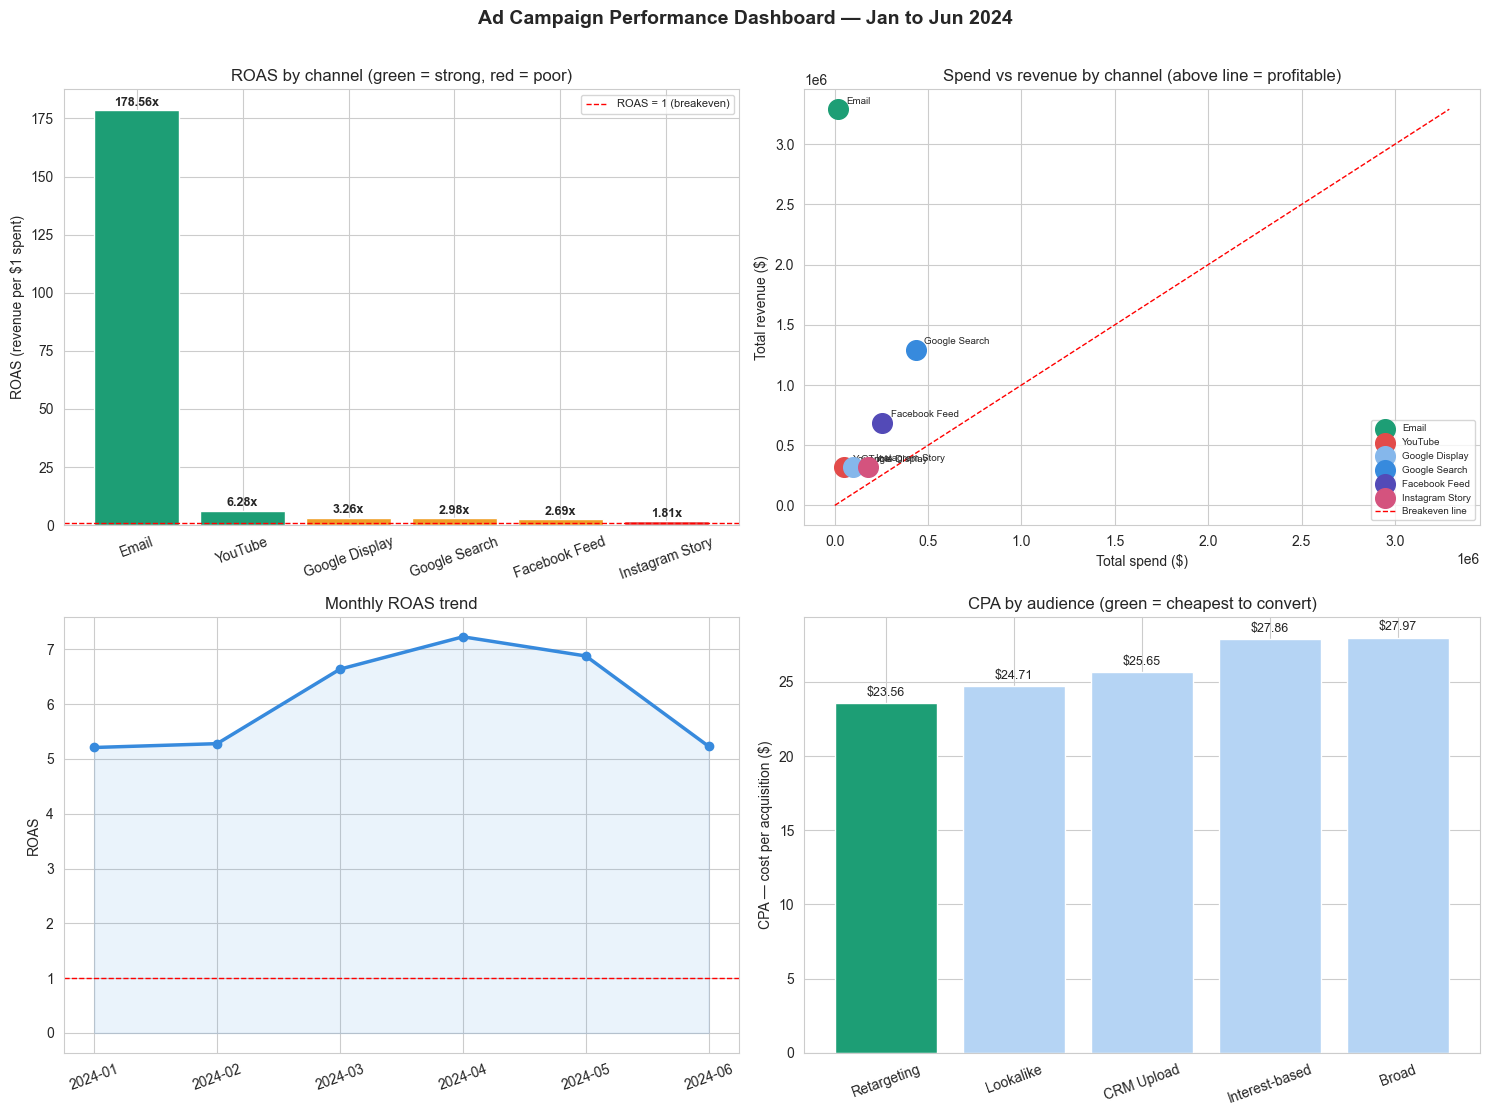

In [7]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Ad Campaign Performance Dashboard — Jan to Jun 2024',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — ROAS by channel
roas_colors = ['#1D9E75' if v >= 5 else '#EF9F27' if v >= 2 else '#E24B4A'
               for v in channel_perf['roas']]
bars1 = axes[0, 0].bar(channel_perf['channel'], channel_perf['roas'], color=roas_colors)
axes[0, 0].axhline(1.0, color='red', linestyle='--', linewidth=1, label='ROAS = 1 (breakeven)')
axes[0, 0].set_ylabel('ROAS (revenue per $1 spent)')
axes[0, 0].set_title('ROAS by channel (green = strong, red = poor)')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend(fontsize=8)
for bar, val in zip(bars1, channel_perf['roas']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f'{val}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2 — Spend vs Revenue scatter
scatter_colors = {'Google Search': '#378ADD', 'Google Display': '#85B7EB',
                  'Facebook Feed': '#534AB7', 'Instagram Story': '#D4537E',
                  'YouTube': '#E24B4A', 'Email': '#1D9E75'}
for _, row in channel_perf.iterrows():
    axes[0, 1].scatter(row['total_spend'], row['total_revenue'],
                       s=200, color=scatter_colors.get(row['channel'], 'gray'),
                       zorder=5, label=row['channel'])
    axes[0, 1].annotate(row['channel'],
                        (row['total_spend'], row['total_revenue']),
                        textcoords='offset points', xytext=(6, 4), fontsize=7)
max_val = max(channel_perf['total_spend'].max(), channel_perf['total_revenue'].max())
axes[0, 1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Breakeven line')
axes[0, 1].set_xlabel('Total spend ($)')
axes[0, 1].set_ylabel('Total revenue ($)')
axes[0, 1].set_title('Spend vs revenue by channel (above line = profitable)')
axes[0, 1].legend(fontsize=7)

# Panel 3 — Monthly ROAS trend
axes[1, 0].plot(monthly_trend['month'], monthly_trend['roas'],
                color='#378ADD', linewidth=2.5, marker='o', markersize=6)
axes[1, 0].fill_between(range(len(monthly_trend)), monthly_trend['roas'],
                         alpha=0.1, color='#378ADD')
axes[1, 0].set_xticks(range(len(monthly_trend)))
axes[1, 0].set_xticklabels(monthly_trend['month'], rotation=20)
axes[1, 0].axhline(1.0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_ylabel('ROAS')
axes[1, 0].set_title('Monthly ROAS trend')

# Panel 4 — CPA by audience
aud_colors = ['#1D9E75' if v == audience_perf['cpa'].min() else '#B5D4F4'
              for v in audience_perf['cpa']]
bars4 = axes[1, 1].bar(audience_perf['audience'], audience_perf['cpa'], color=aud_colors)
axes[1, 1].set_ylabel('CPA — cost per acquisition ($)')
axes[1, 1].set_title('CPA by audience (green = cheapest to convert)')
axes[1, 1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars4, audience_perf['cpa']):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'${val}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('campaign_dashboard.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as campaign_dashboard.png')
plt.show()

## Step 8 — Export + Business Insight Summary

In [8]:
os.makedirs('output', exist_ok=True)

channel_perf.to_csv('output/channel_performance.csv', index=False)
campaign_perf.to_csv('output/campaign_performance.csv', index=False)
monthly_trend.to_csv('output/monthly_trend.csv', index=False)
audience_perf.to_csv('output/audience_performance.csv', index=False)

conn.close()

best_channel  = channel_perf.iloc[0]
worst_channel = channel_perf.iloc[-1]
best_audience = audience_perf.iloc[0]
best_campaign = campaign_perf.iloc[0]
best_day      = dow_perf.iloc[0]
total_spend   = channel_perf['total_spend'].sum()
total_revenue = channel_perf['total_revenue'].sum()
overall_roas  = round(total_revenue / total_spend, 2)

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Period:               Jan 2024 — Jun 2024')
print(f'Total spend:          ${total_spend:,.0f}')
print(f'Total revenue:        ${total_revenue:,.0f}')
print(f'Overall ROAS:         {overall_roas}x')
print(f'Overall ROI:          {round((total_revenue-total_spend)/total_spend*100,1)}%')
print()
print(f'Best channel:         {best_channel["channel"]} — ROAS {best_channel["roas"]}x, CPA ${best_channel["cpa"]}')
print(f'Worst channel:        {worst_channel["channel"]} — ROAS {worst_channel["roas"]}x, CPA ${worst_channel["cpa"]}')
print(f'Best campaign:        {best_campaign["campaign"]} — ROAS {best_campaign["roas"]}x')
print(f'Best audience:        {best_audience["audience"]} — lowest CPA ${best_audience["cpa"]}')
print(f'Best day to run ads:  {best_day["day_of_week"]} — avg ROAS {best_day["avg_roas"]}x')
print()
print('BUDGET REALLOCATION RECOMMENDATION:')
print(f'  1. Scale {best_channel["channel"]} — highest ROAS at {best_channel["roas"]}x')
print(f'  2. Reduce {worst_channel["channel"]} budget — lowest ROAS at {worst_channel["roas"]}x')
print(f'  3. Prioritise {best_audience["audience"]} audience targeting — cheapest conversions')
print(f'  4. Increase spend on {best_day["day_of_week"]} — best avg ROAS of the week')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Period:               Jan 2024 — Jun 2024
Total spend:          $1,030,333
Total revenue:        $6,221,572
Overall ROAS:         6.04x
Overall ROI:          503.8%

Best channel:         Email — ROAS 178.56x, CPA $1.12
Worst channel:        Instagram Story — ROAS 1.81x, CPA $48.9
Best campaign:        Product Launch — ROAS 8.14x
Best audience:        Retargeting — lowest CPA $23.56
Best day to run ads:  Tuesday — avg ROAS 44.5x

BUDGET REALLOCATION RECOMMENDATION:
  1. Scale Email — highest ROAS at 178.56x
  2. Reduce Instagram Story budget — lowest ROAS at 1.81x
  3. Prioritise Retargeting audience targeting — cheapest conversions
  4. Increase spend on Tuesday — best avg ROAS of the week


## Summary

### What we built
A unified SQL-powered ad campaign performance dashboard covering 6 channels, 7 campaigns, and 5 audience segments over 6 months — from raw CSV to actionable budget recommendations.

### Skills practised
- `sqlite3` — load pandas data into SQL, run complex aggregate queries
- `SQL` — GROUP BY, NULLIF, ROUND, computed metrics, multi-table ready schema
- `pandas` — computed columns, read_sql_query, datetime parsing
- `matplotlib` + `seaborn` — 4-panel dashboard, scatter plot, annotated bars
- Marketing metrics — CTR, CPC, CPA, ROAS, ROI calculated from scratch

### Business context
ROAS and CPA are the two metrics every performance marketing manager lives by. A ROAS below 1.0 means you are losing money on every dollar spent. This dashboard replicates what analysts build in Looker Studio or Tableau — but in pure Python + SQL, which means it runs anywhere, on any data, with no licence fees.

### Key findings
Fill these in from your output:
- Best channel (ROAS): Email — ROAS 178.56x, CPA $1.12
- Worst channel (ROAS): Instagram Story — ROAS 1.81x, CPA $48.9
- Best audience (CPA): Retargeting — lowest CPA $23.56
- Overall ROAS: 6.04x
- Best day to run ads: Tuesday — avg ROAS 44.5x